# 🖥️  利用CNN來訓練模型辨別MNIST手寫資料集

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/NN/bin/python


In [2]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### 載入MNIST 資料來源
- MNIST有 60000筆training dataset, 10000 test dataset
- 每張是28x28 灰階影像

In [5]:
(x_train, y_train_raw), (x_test, y_test_raw) = mnist.load_data()

print(x_train.shape, y_train_raw.shape)
print(x_test.shape, y_test_raw.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 查看視覺畫的資料內容（利用matplotlib.pyplot)
- 理解資料長什麼樣子
- 幫助理解後續怎麼清理、調整圖片內容
- Matplotlib的子圖編號是從 1 開始

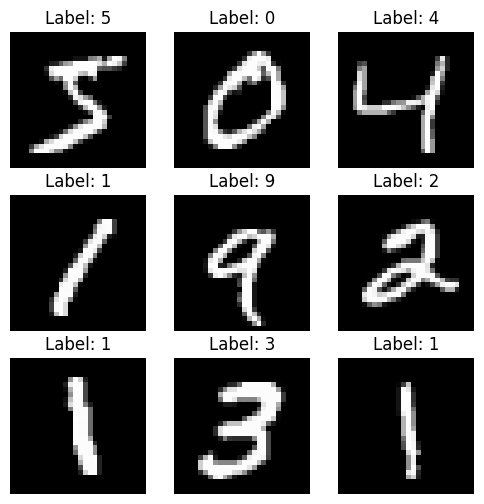

In [7]:
plt.figure(figsize=(6,6)) #建立一個6x6的畫布
for i in range(9): #利用迴圈處理九張圖片
    plt.subplot(3,3,i+1) # 將畫布切成 3 rows and 3 columns 的網格，i+1是告訴城市現在要畫在第幾個格子。
    plt.imshow(x_train[i], cmap='gray') # x_train[i]取出第i張圖片的像素資料, cmap 設定配色方案為灰階
    plt.title(f"Label: {y_train_raw[i]}") # y_train_raw 是對應這張圖片的正確label
    plt.axis('off') # 原本會有座標，但是因為我們只是在看照片，所以可以關掉
plt.show()

### Preprocessing 
#### 正規化(調整尺度) + Reshape(調整為CNN需要的) + One-hot
(1) Normalisation
- 原始資料的pixel值是：0~255的整數
> 除以255.0，是因為NN在處理訓練時用的是 Gradient Descent：
> 如果輸入值太大，梯度會不穩定（震盪、收斂慢、發散）
> 除以255.0可以把輸入縮放到[0,1]區間，梯度穩定

(2) Reshape
- 原始資料shape --> (60000, 28, 28)
- CNN不吃這種格式，Keras的conv2D的期望輸入是：（batch_size, height, width, channels)
- 對灰階影像 channels = 1 (RGB image -> 3 channels)

(3) One-hot Encoding
在處理多分類問題（如 MNIST 數字識別）時，模型的最後一層通常是 Dense(10, activation='softmax')。
- 模型輸出： 一個長度為 10 的機率向量，例如 [0.01, 0.02, 0.90, ...]。
- 計算需求： 為了計算 Loss（Categorical Cross-entropy），標籤（Label）必須與輸出向量的形狀一致。
- 使用to_categorical(y_train_raw, 10) 進行轉換：
| 格式 | 範例 (數字 3) | 說明 |
| :--- | :--- | :--- |
| 原始標籤 (Raw) | 3 | 純數字（Scalar），無法直接進行矩陣運算。 |
| One-hot 標籤 | [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] | 向量（Vector），代表第 4 個位置（索引 3）機率為 100%。|

In [8]:
# 正規化
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

In [9]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### Data Augmentation 數據增強（能提升Generalize)
- 利用 Augmentation 對要丟進去訓練的data set人工模擬domain shift(字會歪、偏移、大小不同）

In [11]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)
datagen.fit(x_train)

### Build CNN Model
#### 🪜CNN 結構設計 Model Architecture
- Sequential是一個模型容器，特點是：資料只能從「上到下」一關接一關傳遞。
    - 為什麼用它
      1. 結構清晰：就像寫待辦清單一樣，第一步做什麼、第二步做什麼，一目瞭然。
      2. 不需要同時跑兩個不同的運算最後再結合
- CNN標準架構：
    - 卷積層（Conv2D): 負責看圖片裡的特徵。
    - 池化層（Maxpooling): 負責濃縮資訊，去掉雜訊，增加平移不變性。
    - 平坦層（Flatten): 把看到的「2D形狀」壓平成「1D清單」。
    - 全連接層（Dense): 最後拿著清單，決定這是哪個數字。
#### 📄 細節
1. 為什麼從32到64？
   - 32: 濾鏡數量較少。這時候模型先學「低階特徵」，例如：橫線、直線、斜角。
   - 64: 增加濾鏡數量。這時模型開始組合之前的線條，學會「高階特徵」，例如：圓圈（由兩個弧線組成）、交叉（由兩條直線組成）
2. 為什麼要Dropout?
   - 為了防止訓練模型時過度擬合(overfitting)。
#### 📖 架構拆解筆記
| 區塊 | 組件內容 | 專業任務 | 目的 |
| :--- | :--- | :--- | :--- |
| **Block 1** | Conv(32) + BN + MaxPool | 初級視覺 | 辨識邊緣、角落，並初步過濾雜訊。 |
| **Block 2** | Conv(64) + BN + MaxPool | 高級視覺 | 辨識局部零件（如圓圈、數字的轉折）。 |
| **轉換層** | Flatten() | 空間降維 | 把圖片矩陣變成一長條數字，準備交給大腦。 |
| **分類器** | Dense(256) + Dense(10) | 邏輯推理 | 根據看到的特徵，判斷機率（這就是 0~9 嗎？）。 |

---

#### 💡 `model.compile` 的規則設定
> 在定義完神經網路架構後，模型就像是一個「尚未受訓的大腦」。
> `model.compile` 的作用是設定**訓練規則**，決定模型如何學習與自我修正。

1. 核心參數解析
| 參數名稱 | 專業術語 | 比喻 | 功能說明 |
| :--- | :--- | :--- | :--- |
| **optimizer** | 最佳化器 | **導航員** | 決定如何更新權重。負責指引模型朝向「損失最小」的方向前進。 |
| **loss** | 損失函數 | **挫折感** | 計算預測值與正確答案的差距。數值越高，代表模型預測得越離譜。 |
| **metrics** | 評估指標 | **計分板** | 訓練過程中的參考數據（主要給人看），最常用的是 `accuracy` (準確率)。 |

2. 除了 Adam，我還有哪些最佳化器 (Optimizer) 可選？

雖然 `Adam` 是目前最通用的「全能選手」，但根據不同的任務需求，你也可以更換其他的導航員：
| 最佳化器 | 特點說明 | 適用場景 |
| :--- | :--- | :--- |
| **Adam** | 結合了動量與自動調整學習率的優點。 | **最推薦！** 適合大多數初學者與通用任務。 |
| **SGD** | 傳統的隨機梯度下降。雖然收斂慢，但有時能找到更穩定的解。 | 適合搭配 `momentum` 參數處理複雜的影像分類。 |
| **RMSprop** | 專門調整學習率，防止訓練後期震盪。 | 循環神經網路 (RNN) 或處理時間序列數據時表現優異。 |
| **Adagrad** | 針對出現頻率較低的特徵給予較大的更新。 | 適合處理稀疏數據 (Sparse Data)。 |


In [13]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='categorical_crossentropy', 
    metrics=['accuracy'])

model.summary()

/opt/anaconda3/envs/NN/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,018 (3.32 MB)

 Trainable params: 870,826 (3.32 MB)

 Non-trainable params: 192 (768.00 B)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, #如果連續 5 個 Epoch 沒進步，就停駛訓練
    restore_best_weights=True # 訓練停止時，通常已經退步5次了，這個參數可以讓模型回到表現最好的那一刻
)

reduce_lr = ReduceLROnPlateau( #LR = learning rate
    monitor='val_loss', #監控驗證及的損失
    patience=3, #如果連續三個Epoch, val_loss都沒進步，就觸發降速。
    factor=0.5, #把LR*0.5，縮小步幅，讓模型更精緻的調整權重，慢慢滑到那個最精準的凹槽
    verbose=1, 
)

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128), #一次餵給模型128張照片，數字越大訓練越快，但也越吃GPU
    epochs=30, #尋遍資料集30次
    validation_data=(x_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30


/opt/anaconda3/envs/NN/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.5550 - loss: 1.4222 - val_accuracy: 0.9805 - val_loss: 0.1251 - learning_rate: 0.0010
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9089 - loss: 0.2924 - val_accuracy: 0.9856 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9443 - loss: 0.1858 - val_accuracy: 0.9876 - val_loss: 0.0432 - learning_rate: 0.0010
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.9599 - loss: 0.1370 - val_accuracy: 0.9905 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9689 - loss: 0.1066 - val_accuracy: 0.9931 - val_loss: 0.0203 - learning_rate: 0.0010
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.9746 - loss: 0.0953 - val_accuracy: 0.9929 - val_loss: 0.0221 - learning_rate: 0.0010
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9778 - loss: 0.0789

In [15]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"MNIST Test Accuracy: {acc*100:.2f}%")

MNIST Test Accuracy: 99.65%


### 看到什麼才是「健康模型」？

- Accuracy：training & validation 都上升，最後貼近
- Loss：training & validation 都下降，沒有分岔
> 沒有明顯「train ↑ 但 val ↓」的交叉，這剛好可以佐證「沒有過度擬合」

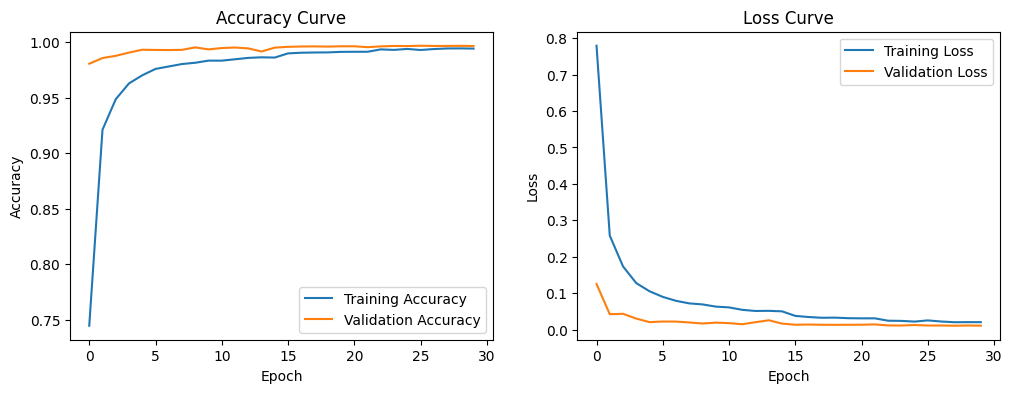

In [16]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

In [17]:
model.save("cw1_mnist_cnn_tf218.h5")